# Imports

In [1]:
from langchain_groq import ChatGroq # for LLM
from langchain_huggingface.embeddings import HuggingFaceEmbeddings # for embeddings model
from langchain.tools import tool # for custome tools
from langchain_community.document_loaders.csv_loader import CSVLoader # for loading csv file
from langchain_text_splitters import RecursiveCharacterTextSplitter # for chunking data
from langchain_community.vectorstores import FAISS # for vector db
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage # for messaging type
from langgraph.graph.message import add_messages # for message adding
from langchain_tavily import TavilySearch # for web search
# for langgraph workflow
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
import os
# env
from dotenv import load_dotenv
load_dotenv("../.env")

c:\Users\LENOVO\OneDrive\Desktop\AgenticRAG\venv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
c:\Users\LENOVO\OneDrive\Desktop\AgenticRAG\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

# Model

In [2]:
llm = ChatGroq(model="moonshotai/kimi-k2-instruct-0905", api_key=os.getenv("GROQ_API_KEY"))
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

loading csv data

In [3]:
all_docs = []

for csv_path in ["../datasets/data_preprocessed/device_manuals.csv", "../datasets/data_preprocessed//question_answer.csv"]:
    if os.path.exists(csv_path):
        loader = CSVLoader(file_path=csv_path, encoding="latin1")
        docs = loader.load()  # Each row = 1 Document
        all_docs.extend(docs)  # Keep Document objects

chunking docs

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=200)
texts = text_splitter.split_documents(all_docs)

storing results in FAISS vector store.

In [5]:
vector_db = FAISS.from_documents(texts, embeddings)

KeyboardInterrupt: 

# Tools

vector search tool

In [ ]:
@tool("vector_search", description="Search the device manuals and question answer database for relevant documents.")
def vector_search(query: str):
    """Retrieves top 5 results from FAISS for a given query."""
    try:
        retriever = vector_db.as_retriever(search_type='similarity', search_kwargs={'k': 5})
        result = retriever.invoke(query)
        context = "\n\n".join([doc.page_content for doc in result])
        return context
    except Exception as e:
        return f"Vector search Error: {str(e)}"

tavily search tool

In [ ]:
tavily_search_tool = TavilySearch(max_results=5,topic="general")

@tool("website_search", description="search on web using tavily search for the latest information.")
def website_search(query):
    """Up-to-date web info via Tavily"""
    try:
        result = tavily_search_tool.invoke({"query": query})

        # Extract and format the results from Tavily response
        if isinstance(result, dict) and 'results' in result:
            formatted_results = []
            for item in result['results']:
                title = item.get('title', 'No title')
                content = item.get('content', 'No content')
                url = item.get('url', '')
                formatted_results.append(f"Title: {title}\nContent: {content}\nURL: {url}")

            return "\n\n".join(formatted_results) if formatted_results else "No results found"
        else:
            return str(result)
    except Exception as e:
        return f"WEB_ERROR::{e}"

# Lang graph state

In [ ]:
class ChatState(TypedDict):
    question: str # question from the user
    messages: Annotated[List[BaseMessage], add_messages] # all messages history
    phase: str # current phase of the chat web or rag
    rag_context: str # context from the rag
    web_context: str # context from the web

# Nodes

planning node (Tells the agent what the execution workflow will be)

In [ ]:
def planning(state: ChatState):
   print("Planning node started")

   fixed_spelling = llm.invoke(f"Fix the spelling, syntax and any other grammatical errors in the question and just give question donot give aything else: {state['question']}.").content
   SYSTEM_PROMPT = """
      You are an Agentic RAG assistant.

      You MUST follow these rules exactly:

         1. Use vector surch node for each and every question.
         2. If the question is not found in the vector store, use web search node.
         3. If the question is not found in the web search, use fall back llm node.
   
      """

   system = SystemMessage(
      content=SYSTEM_PROMPT  
   )
   user = HumanMessage(content=fixed_spelling)

   print("Planning node finised")
   return {
      "messages": [system, user],
      "question": fixed_spelling,
      "phase": "rag"
   }


context search node (this node will bring the context from evaluating rag)

In [ ]:
def context_search(state: ChatState):
    print("context search started")
        
    context_search = vector_search.invoke(state["question"])

    prompt = f"""
      You are a retrieval-augmented generation (RAG) assistant.

      Your job is to answer the user's question using ONLY the provided context.
      The context comes from a knowledge base and may include multiple documents.

      Rules:
        - If the answer is in the context, use it and cite it implicitly.
        - If the context does NOT contain the answer, say:
          "I don't know based on the provided information."
        - Do NOT use prior knowledge or make up facts.
        - Do NOT hallucinate.
        - Be concise, clear, and factual.

      Question:
        {state['question']}

      Context:
        {context_search}
      """

    llm_res = llm.invoke(prompt).content
    
    print("context search finised")
    return {"rag_context": llm_res, "phase": "rag"}


check relevence node (this node will check if the searched context from rag and web are good enough or they requre more searching)

In [ ]:
def check_relevence(state: ChatState):
    print("check relevence started")
    
    if state["phase"] == "rag":
        context = state["rag_context"]
    else:
        context = state["web_context"]

    judge_prompt = f"""
    Question: {state['question']}
    Context:
    {context}

    Review the context above and determine if it provides a COMPLETE answer to ALL parts of the user's question: "{state['question']}".
    If ANY part of the question cannot be answered using the provided context, respond with NO.
    Only respond with YES if EVERYTHING in the question can be answered using only the provided context.
    Reply only YES or NO.
    """

    decision = llm.invoke(judge_prompt).content.strip().upper()

    print("check relevance finished")
    if "YES" in decision:
        state["messages"].append(AIMessage(content=context))
        return {"phase": "end"}
    else:
        if state["phase"] == "web":
            return {"phase": "fall_back_llm"}
        return {"phase": "web"}


fallback llm node

In [ ]:
def fall_back_llm(state: ChatState):
    print("fallback node started")
    prompt = f"""
    Answer the following question using your knowledge.
    Do NOT use tools.
    Keep the answer high-level, educational and professional.

    Question: {state['question']}
    """

    answer = llm.invoke(prompt).content

    print("fall back node finished")
    return {
        "messages": [AIMessage(content=answer)],
        "phase": "end"
    }


web search node (this node will decide give us web search results)

In [ ]:
def web_search(state: ChatState):
    print("web search started")
    
    web_search = website_search.invoke(state["question"])

    prompt = f"""
      You are a retrieval-augmented generation (RAG) assistant.

      Your job is to answer the user's question using ONLY the provided context.
      The context comes from a knowledge base and may include multiple documents.

      Rules:
        - If the answer is in the context, use it and cite it implicitly.
        - If the context does NOT contain the answer, say:
          "I don't know based on the provided information."
        - Do NOT use prior knowledge or make up facts.
        - Do NOT hallucinate.
        - Be concise, clear, and factual.

      Question:
        {state['question']}

      Context:
        {web_search}
      """
  
    llm_res = llm.invoke(prompt).content
    
    print("web search finised")
    return {"web_context": llm_res, "phase": "web"}


In [ ]:
def return_phase(state: ChatState):
    """Routing function for check_relevence conditional edges"""
    return state["phase"]

# Graph

In [ ]:
graph = StateGraph(ChatState)

creating all nodes

In [ ]:
graph.add_node('planning', planning)
graph.add_node('context_search', context_search)
graph.add_node('check_relevence', check_relevence)
graph.add_node('web_search', web_search)
graph.add_node("fall_back_llm", fall_back_llm)

creating add edges

In [ ]:
graph.add_edge(START, "planning")
graph.add_edge('planning', 'context_search')
graph.add_edge('context_search', "check_relevence")
graph.add_conditional_edges("check_relevence", return_phase, {"web": "web_search", "end": END, "fall_back_llm": "fall_back_llm"})
graph.add_edge('web_search', "check_relevence")
graph.add_edge("fall_back_llm", END)

compiling graph

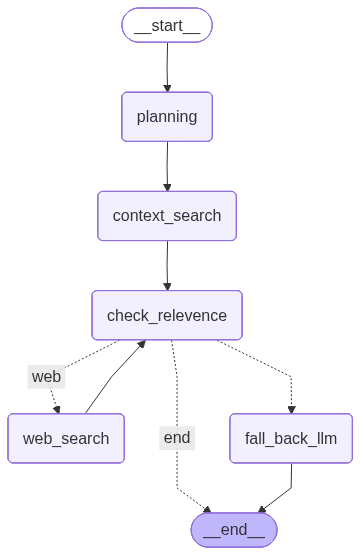

In [ ]:
chatbot = graph.compile()
chatbot

# Question to agent

web search

In [ ]:
initial_state = {
    'question': "Who is the current Prime Minister of Pakistan?"
}

res = chatbot.invoke(initial_state)
res

Planning node started
Planning node finised
context search started
context search finised
check relevence started
check relevance finished
web search started


Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.


web search finised
check relevence started


Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.


check relevance finished


{'question': 'Who is the current Prime Minister of Pakistan?',
 'messages': [SystemMessage(content='\n      You are an Agentic RAG assistant.\n\n      You MUST follow these rules exactly:\n\n         1. Use vector surch node for each and every question.\n         2. If the question is not found in the vector store, use web search node.\n         3. If the question is not found in the web search, use fall back llm node.\n\n      ', additional_kwargs={}, response_metadata={}, id='ae3d14bd-ad9b-4a7a-99b3-52415ee17bf7'),
  HumanMessage(content='Who is the current Prime Minister of Pakistan?', additional_kwargs={}, response_metadata={}, id='6c7d1ab2-2584-48d1-9b59-2e963d861fbc'),
  AIMessage(content='Shehbaz Sharif is the current Prime Minister of Pakistan, in office since 4 March 2024.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'phase': 'end',
 'rag_context': "I don't know based on the provided information.",
 'web_context': 'Shehbaz Sharif is th

In [ ]:
ai_msg = res["messages"][-1].content
print(ai_msg)

Shehbaz Sharif is the current Prime Minister of Pakistan, in office since 4 March 2024.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.


fallback node search

In [ ]:
initial_state = {
    'question': "Tell me what deseases i can get by eating raw fishes"
}

res = chatbot.invoke(initial_state)
res

Planning node started
Planning node finised
context search started
context search finised
check relevence started
check relevance finished
web search started


Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.
Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.


web search finised
check relevence started
check relevance finished
fallback node started


Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.


fall back node finished


{'question': 'What diseases can I get by eating raw fish?',
 'messages': [SystemMessage(content='\n      You are an Agentic RAG assistant.\n\n      You MUST follow these rules exactly:\n\n         1. Use vector surch node for each and every question.\n         2. If the question is not found in the vector store, use web search node.\n         3. If the question is not found in the web search, use fall back llm node.\n\n      ', additional_kwargs={}, response_metadata={}, id='9e8cd1e3-ad41-46e3-811a-aa859ba59f96'),
  HumanMessage(content='What diseases can I get by eating raw fish?', additional_kwargs={}, response_metadata={}, id='03bb185d-0b5c-4c0b-9eba-7f5b71ec3438'),
  AIMessage(content='Raw-fish–associated illnesses fall into three main groups:\n\n1. Parasitic  \n   – Anisakiasis (Anisakis worms) – causes severe abdominal pain, nausea, vomiting hours to days after ingestion.  \n   – Diphyllobothriasis (broad fish tapeworm) – usually mild, but can lead to vitamin-B12 deficiency and m

In [ ]:
ai_msg = res["messages"][-1].content
print(ai_msg)

Raw-fish–associated illnesses fall into three main groups:

1. Parasitic  
   – Anisakiasis (Anisakis worms) – causes severe abdominal pain, nausea, vomiting hours to days after ingestion.  
   – Diphyllobothriasis (broad fish tapeworm) – usually mild, but can lead to vitamin-B12 deficiency and megaloblastic anemia.  
   – Opisthorchiasis/Clonorchiasis (liver flukes) – chronic infection can produce cholangitis, gall-stones, and decades later cholangiocarcinoma.

2. Bacterial  
   – Vibrio parahaemolyticus & V. vulnificus – explosive watery diarrhea; V. vulnificus can invade the bloodstream in liver-disease patients and cause life-threatening sepsis.  
   – Salmonella spp. – enterocolitis with fever, bloody diarrhea.  
   – Listeria monocytogenes – flu-like illness that may progress to meningitis in pregnant or immunocompromised hosts.  
   – Aeromonas & Plesiomonas – dysenteric or cholera-like illness.

3. Viral  
   – Norovirus & hepatitis A virus – acute gastroenteritis or hepatitis 

Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.


rag search

In [ ]:
initial_state = {
    'question': "What are the treatments for Chapare Hemorrhagic Fever (CHHF) ?"
}

res = chatbot.invoke(initial_state)
res

Planning node started
Planning node finised
context search started


Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.


context search finised
check relevence started
check relevance finished


{'question': 'What are the treatments for Chapare hemorrhagic fever (CHHF)?',
 'messages': [SystemMessage(content='\n      You are an Agentic RAG assistant.\n\n      You MUST follow these rules exactly:\n\n         1. Use vector surch node for each and every question.\n         2. If the question is not found in the vector store, use web search node.\n         3. If the question is not found in the web search, use fall back llm node.\n\n      ', additional_kwargs={}, response_metadata={}, id='90b52e9b-734f-4b7a-9372-4f9e5a69e9dd'),
  HumanMessage(content='What are the treatments for Chapare hemorrhagic fever (CHHF)?', additional_kwargs={}, response_metadata={}, id='5bd93efd-646a-44ca-bf0a-2d9cbd02cfa1'),
  AIMessage(content='Supportive therapy is the main treatment for Chapare hemorrhagic fever. This includes maintaining hydration, managing shock, providing sedation and pain relief, observing bleeding-precaution protocols, and giving transfusions when necessary. Ribavirin has been cons

In [ ]:
ai_msg = res["messages"][-1].content
print(ai_msg)

Supportive therapy is the main treatment for Chapare hemorrhagic fever. This includes maintaining hydration, managing shock, providing sedation and pain relief, observing bleeding-precaution protocols, and giving transfusions when necessary. Ribavirin has been considered as a potential antiviral option.


Failed to send compressed multipart ingest: langsmith.utils.LangSmithUserError: This API key is org-scoped and requires workspace specification. Please provide 'workspace_id' parameter, or set LANGSMITH_WORKSPACE_ID environment variable.
